<a href="https://colab.research.google.com/github/241541601038-glitch/JALIZ/blob/main/EX13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving pedestrian.jpg to pedestrian.jpg


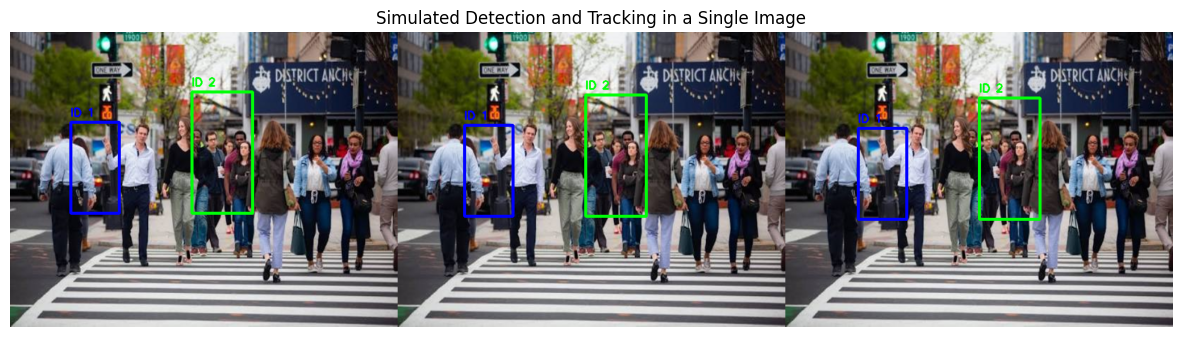

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Image_path = '/content/pedestrian.jpg'
Image = cv2.imread(Image_path)
Image = cv2.resize(Image, (640, 488))

# Initialize a list to hold the completely processed image for each time step
final_processed_frames = []

# Rename 'frame' to 'initial_frames_copies' to avoid shadowing in the loop
initial_frames_copies = [Image.copy() for _ in range(3)]

objects = [(100, 150, 80, 150), (300, 100, 100, 200)]
colors = [(255, 0, 0), (8, 255, 0)]

# Loop through each time step (or "frame" in the original context)
for i, base_frame in enumerate(initial_frames_copies):
    # Create a fresh copy of the base image for this time step
    current_frame_with_objects = base_frame.copy()

    # Draw all objects for the current time step on this frame
    for j, (x, y, w, h) in enumerate(objects):
        new_x, new_y = x + i * 10, y + i * 5
        cv2.rectangle(current_frame_with_objects, (new_x, new_y), (new_x + w, new_y + h), colors[j], 3)
        cv2.putText(current_frame_with_objects, f"ID {j+1}", (new_x, new_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors[j], 2)

    # After all objects are drawn for this 'i', add the fully processed frame to our list
    final_processed_frames.append(current_frame_with_objects)

# Now, outside the loops, combine all the final processed frames horizontally
if final_processed_frames:
    combined_image_final = np.hstack(final_processed_frames)
    combined_image_final_rgb = cv2.cvtColor(combined_image_final, cv2.COLOR_BGR2RGB)

    # Display the single combined image
    plt.figure(figsize=(15, 5))
    plt.imshow(combined_image_final_rgb)
    plt.axis('off')
    plt.title("Simulated Detection and Tracking in a Single Image")
    plt.show()